# EDA & Tiền xử lý — WHO Life Expectancy (`Life Expectancy Data.csv`)

Bài toán **hồi quy**: dự đoán `Life expectancy` (tuổi thọ trung bình). Cùng luồng **clean-first** với các notebook trước,
nhưng bộ này **đặc biệt nhiều missing (2.563 ô)** và tên cột dính dấu cách thừa → trọng tâm là **làm sạch + điền thiếu**.
Dữ liệu dạng **panel** (193 quốc gia × các năm 2000–2015). Mỗi bước gồm **Lý do** và **Phân tích** (số liệu từ output thật).

> ⚠️ Target `Life expectancy` được **giữ nguyên gốc** — chỉ **bỏ dòng thiếu target**, không log/scale.

## 0. Thiết lập môi trường

Mount Google Drive và đặt thư mục làm việc.
> Chạy local thì bỏ 2 dòng `drive`/`os.chdir` và trỏ thẳng đường dẫn ở bước 1.

In [6]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/AIO-Conquer02')
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/AIO-Conquer02'

## 1. Nạp & kiểm tra tổng quan

**Lý do:** `info()` để nắm kích thước, kiểu dữ liệu, mức độ đầy đủ.

In [7]:
import pandas as pd
import numpy as np
df = pd.read_csv('Life Expectancy Data.csv')
print('Tên cột GỐC (chú ý dấu cách thừa):')
print(df.columns.tolist())
df.info()

Tên cột GỐC (chú ý dấu cách thừa):
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   A

> 📊 **Phân tích:** **2.938 dòng × 22 cột** — 20 cột số + 2 cột chữ (`Country`, `Status`). **Rất nhiều cột thiếu dữ liệu**
> (Non-Null < 2.938). Tên cột **bị dính dấu cách thừa** (`'Life expectancy '`, `' BMI '`, `'thinness  1-19 years'`) → dễ gây lỗi
> khi gọi cột, cần **strip** trước. Dữ liệu là **panel**: mỗi quốc gia lặp qua nhiều năm.

## 2. Cleaning bước 1 — chuẩn hoá tên cột

**Lý do:** Xoá dấu cách thừa ở đầu/cuối tên cột để truy cập cột nhất quán, tránh bug khó thấy.

In [8]:
df.columns = df.columns.str.strip()
print('Tên cột sau khi strip:')
print(df.columns.tolist())

Tên cột sau khi strip:
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


> 📊 **Phân tích:** Tên cột giờ sạch (`Life expectancy`, `BMI`, `thinness 1-19 years`...). Đây là bước nhỏ nhưng **quan trọng** —
> nhiều lỗi `KeyError` về sau xuất phát từ dấu cách thừa này.

### Cấu trúc panel & biến phân loại
**Lý do:** Xem số quốc gia, khoảng năm, và phân bố `Status`.

In [9]:
print('Số quốc gia:', df['Country'].nunique())
print('Khoảng năm:', df['Year'].min(), '->', df['Year'].max())
print('Status:', df['Status'].value_counts().to_dict())
df[['Country', 'Status']].nunique().to_frame('n_unique')

Số quốc gia: 193
Khoảng năm: 2000 -> 2015
Status: {'Developing': 2426, 'Developed': 512}


,n_unique
Country,193
Status,2


> 📊 **Phân tích:** **193 quốc gia** × **2000–2015**. `Status` nhị phân: **Developing (2.426)** áp đảo **Developed (512)** —
> mất cân bằng. `Country` cardinality **rất cao (193)** → không one-hot trực tiếp (sẽ tạo 193 cột); tính panel này cũng
> rất hữu ích để **điền thiếu theo từng quốc gia** (bước 5).

## 3. Phân tích missing — phần quan trọng nhất

**Lý do:** Bộ này thiếu nhiều và **không đều giữa các cột** → cần đo tỉ lệ thiếu từng cột để chọn cách xử lý.

Tổng ô missing: 2563


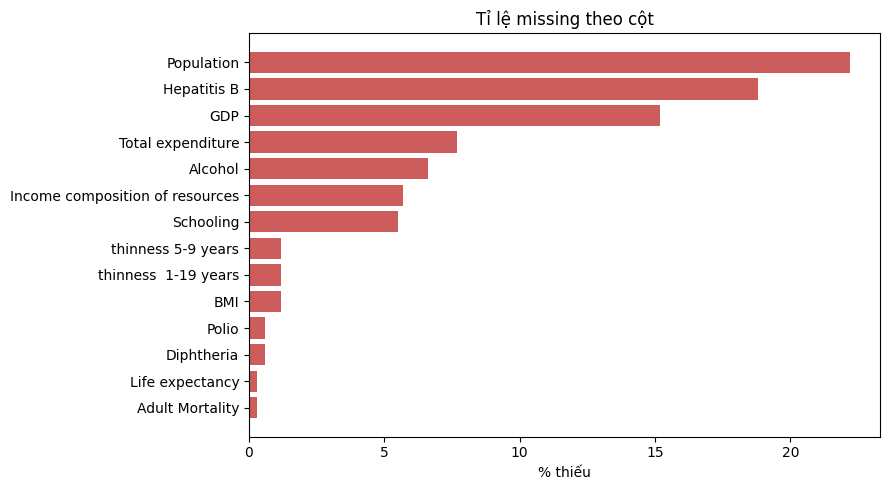

,n_missing,pct_%
Population,652,22.2
Hepatitis B,553,18.8
GDP,448,15.2
Total expenditure,226,7.7
Alcohol,194,6.6
Income composition of resources,167,5.7
Schooling,163,5.5
thinness 5-9 years,34,1.2
thinness 1-19 years,34,1.2
BMI,34,1.2


In [10]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_tbl = pd.DataFrame({'n_missing': miss, 'pct_%': (miss / len(df) * 100).round(1)})
print('Tổng ô missing:', int(df.isna().sum().sum()))
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.barh(miss_tbl.index[::-1], miss_tbl['pct_%'][::-1], color='indianred')
plt.xlabel('% thiếu'); plt.title('Tỉ lệ missing theo cột'); plt.tight_layout(); plt.show()
miss_tbl

> 📊 **Phân tích:** Tổng **2.563 ô thiếu**. Nặng nhất: **`Population` 22,2%** (652), **`Hepatitis B` 18,8%** (553),
> **`GDP` 15,2%** (448), `Total expenditure` 7,7%, `Alcohol` 6,6%, `Income composition`/`Schooling` ~5,6%. Đáng chú ý
> **target `Life expectancy` thiếu 10 dòng** và `Adult Mortality` thiếu 10. → chiến lược: **bỏ dòng thiếu target**
> (không học được), **điền feature** bằng trung vị theo quốc gia (tận dụng panel) + fallback trung vị toàn cục.

## 4. Cleaning bước 2 — bỏ dòng thiếu TARGET

**Lý do:** Dòng không có `Life expectancy` không dùng được cho học có giám sát → loại (chỉ 10 dòng, ~0,3%).
**Không** điền target để tránh tạo nhãn giả.

In [11]:
before = len(df)
df = df.dropna(subset=['Life expectancy']).reset_index(drop=True)
print(f'Đã bỏ {before - len(df)} dòng thiếu target | còn {len(df)} dòng')

Đã bỏ 10 dòng thiếu target | còn 2928 dòng


> 📊 **Phân tích:** Còn **2.928 dòng**. Target giờ đầy đủ 100%, các cột feature vẫn còn thiếu (xử lý ở bước 5).

## 5. Phân phối & độ lệch các biến số

**Lý do:** Histogram để thấy biến nào lệch mạnh (ảnh hưởng cách điền & cần log) và phân phối target.

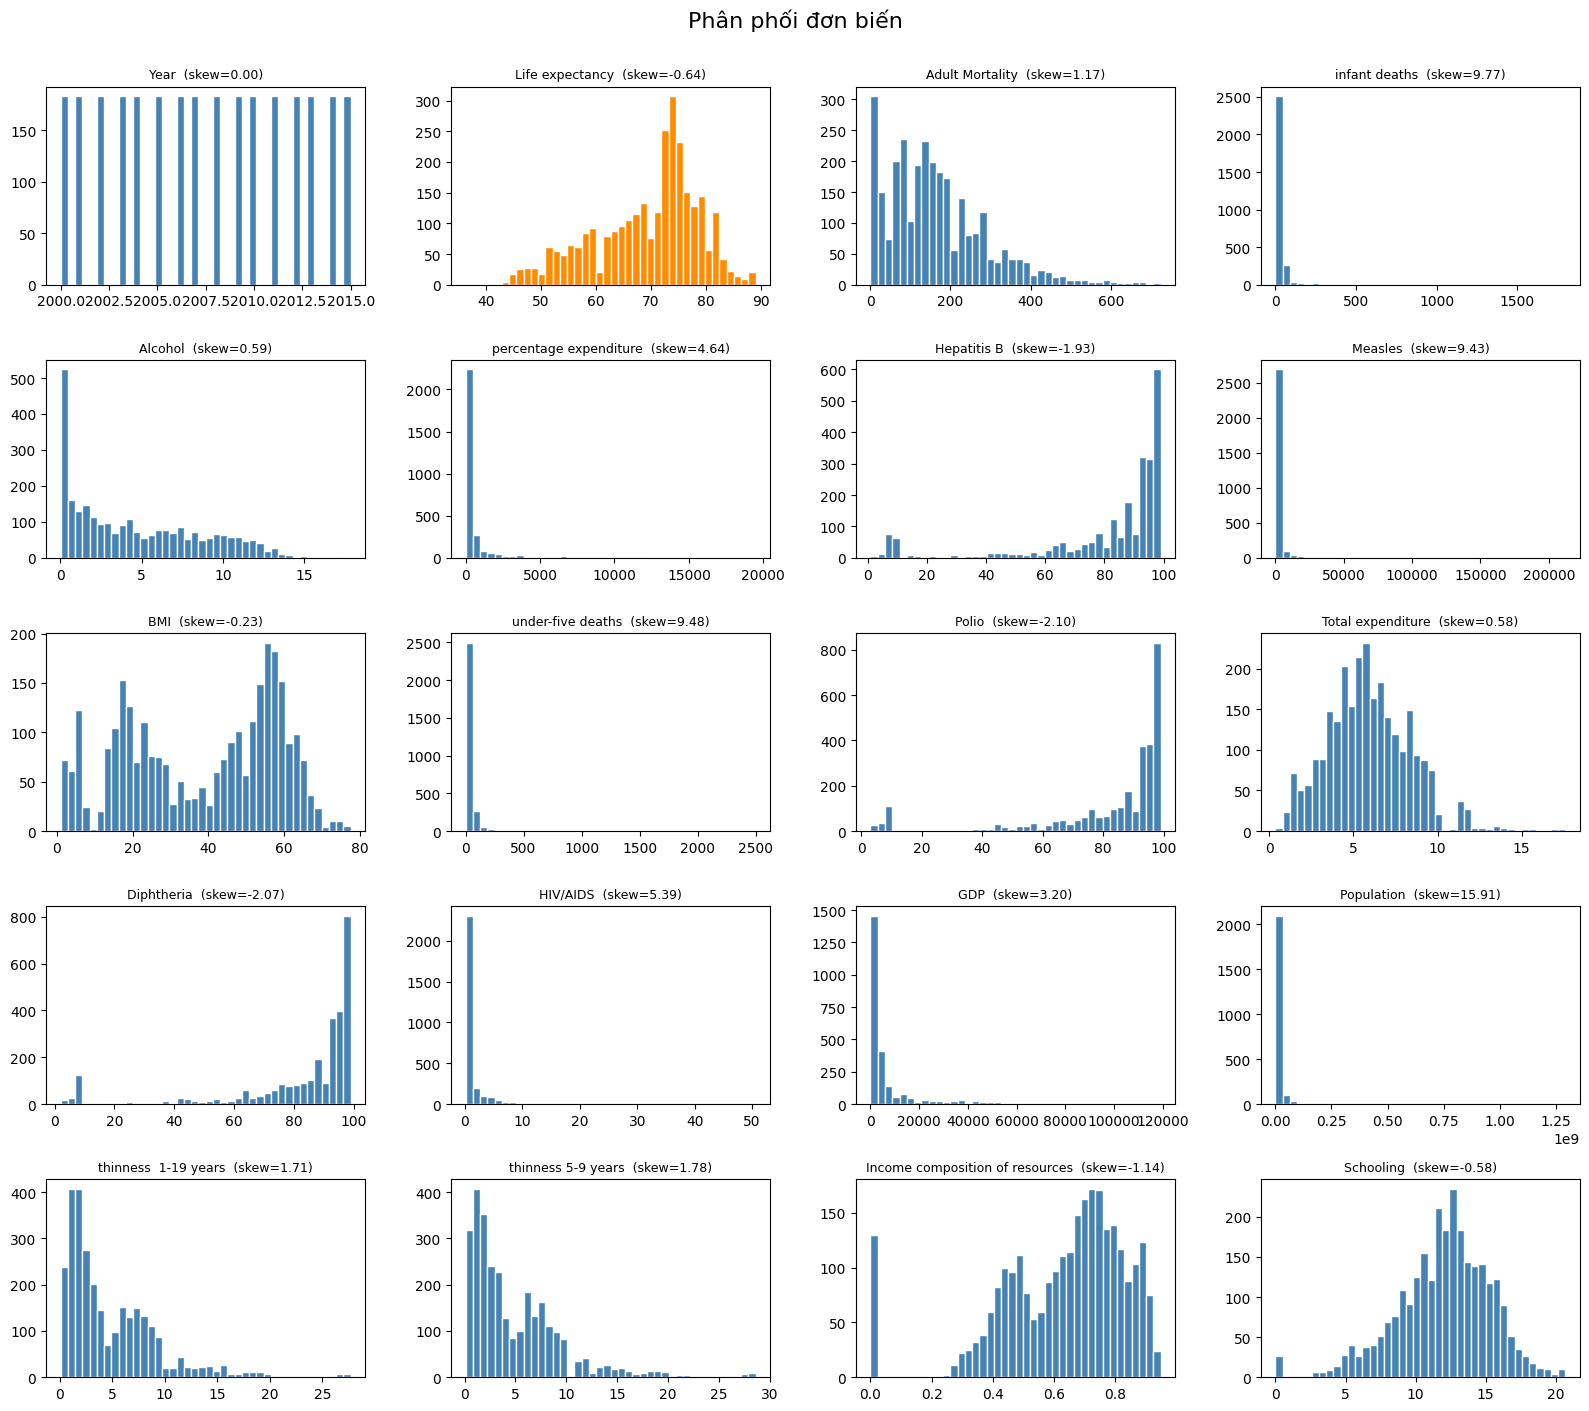

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
ncols = 4; nrows = int(np.ceil(len(num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.0, nrows * 2.8)); axes = axes.flatten()
for i, c in enumerate(num_cols):
    color = 'darkorange' if c == 'Life expectancy' else 'steelblue'
    axes[i].hist(df[c].dropna(), bins=40, color=color, edgecolor='white')
    axes[i].set_title(f'{c}  (skew={df[c].skew():.2f})', fontsize=9); axes[i].set_ylabel('')
for j in range(len(num_cols), len(axes)): axes[j].set_visible(False)
plt.suptitle('Phân phối đơn biến', fontsize=16, y=1.005); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Target `Life expectancy` **lệch trái nhẹ** (skew −0,64; đa số 60–80 tuổi, đuôi thấp tới 36). Nhiều feature
> **lệch phải cực mạnh**: `Population` (15,9), `infant deaths` (9,8), `under-five deaths` (9,5), `Measles` (9,4), `HIV/AIDS` (5,4),
> `percentage expenditure` (4,65), `GDP` (3,2) → ứng viên **log**. Vài biến tỉ lệ tiêm chủng lệch trái (`Polio`/`Diphtheria` ~−2,1;
> đa số nước phủ ~90%+). → nên dùng **trung vị** (robust) để điền thay vì trung bình.

## 6. Outlier & giá trị nghi vấn

**Lý do:** Boxplot vài biến đếm để soi cực trị (bộ này nổi tiếng có vài số liệu nghi sai như `infant deaths` quá lớn).

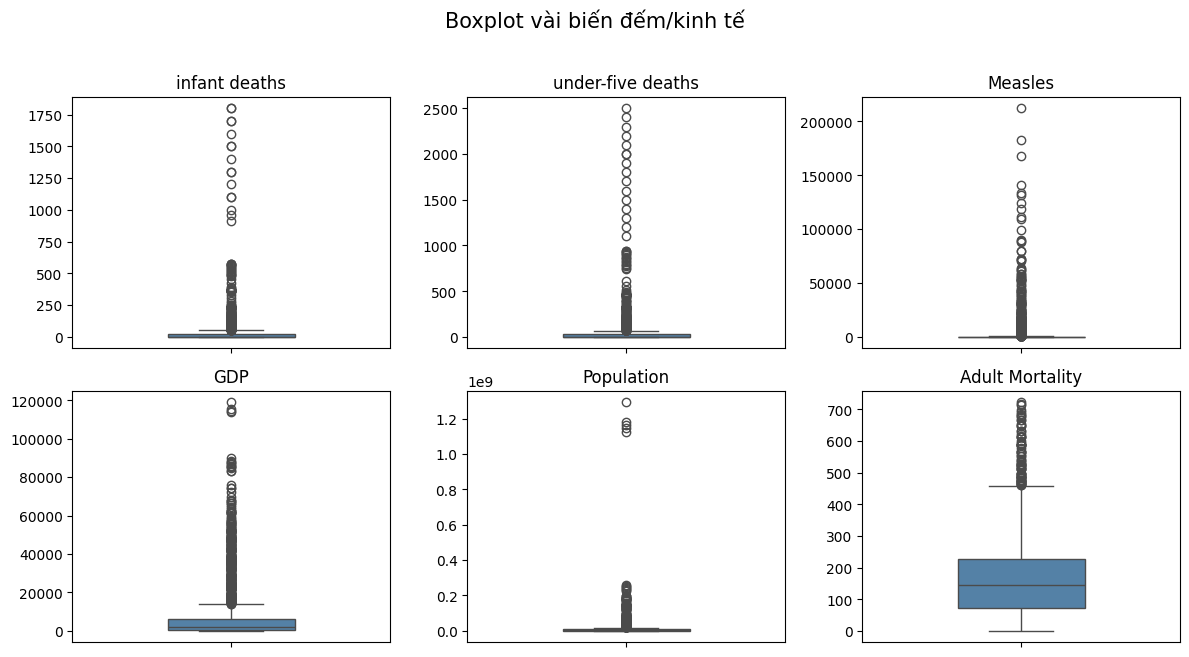

infant deaths max: 1800 | under-five deaths max: 2500


In [13]:
import seaborn as sns
check = ['infant deaths', 'under-five deaths', 'Measles', 'GDP', 'Population', 'Adult Mortality']
n = len(check); ncols = 3; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.2)); axes = axes.flatten()
for i, c in enumerate(check):
    sns.boxplot(y=df[c], ax=axes[i], color='steelblue', width=0.4); axes[i].set_title(c); axes[i].set_ylabel('')
for j in range(n, len(axes)): axes[j].set_visible(False)
plt.suptitle('Boxplot vài biến đếm/kinh tế', fontsize=15, y=1.02); plt.tight_layout(); plt.show()
print('infant deaths max:', int(df['infant deaths'].max()), '| under-five deaths max:', int(df['under-five deaths'].max()))

> 📊 **Phân tích:** `infant deaths` lên tới **1.800** và `under-five deaths` tới **2.500** — về danh nghĩa là "trên 1000 dân"
> nên các giá trị này **nghi sai/đơn vị không nhất quán** (đặc trưng đã biết của bộ WHO này). `Measles` tới hơn 212k, `Population`/`GDP`
> lệch cực mạnh. → các cực trị này **không xoá** (sẽ mất nhiều dữ liệu), mà nên **log + scale robust** ở bước model; lưu ý cặp
> `infant deaths`/`under-five deaths` gần như trùng thông tin.

## 7. Cleaning bước 3 — điền thiếu (trung vị theo quốc gia)

**Lý do:** Vì là **panel theo quốc gia**, giá trị của một nước qua các năm khá ổn định → điền bằng **trung vị của chính quốc gia đó**
là hợp lý nhất (giữ đặc trưng từng nước). Nước nào thiếu sạch một cột thì **fallback trung vị toàn cục**. Dùng **trung vị** vì
nhiều biến lệch mạnh.

In [14]:
df_imp = df.copy()
num_cols = df_imp.select_dtypes(include=np.number).columns.tolist()
for c in num_cols:
    # trung vị theo từng quốc gia
    df_imp[c] = df_imp.groupby('Country')[c].transform(lambda s: s.fillna(s.median()))
    # fallback: trung vị toàn cục cho nước thiếu sạch cột đó
    df_imp[c] = df_imp[c].fillna(df_imp[c].median())
print('Missing sau khi điền:', int(df_imp.isna().sum().sum()))
df_imp.isna().sum().to_frame('n_missing').T

Missing sau khi điền: 0


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
n_missing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


> 📊 **Phân tích:** **0 missing** sau khi điền. Ưu điểm: điền theo quốc gia giữ được mức nền riêng của từng nước
> (vd `Population`, `GDP` rất khác nhau giữa các nước), tốt hơn nhiều so với nhét một trung vị toàn cục cho tất cả.
> ⚠️ Lưu ý leakage: ở pipeline thật nên **fit thống kê điền trên train** rồi áp cho test; ở đây điền theo quốc gia ít rủi ro hơn
> vì không dùng tới target.

## 8. Ma trận tương quan với target

**Lý do:** Sau khi đủ dữ liệu, dùng heatmap Pearson (biến số) để xem yếu tố nào liên hệ mạnh với tuổi thọ + đa cộng tuyến.

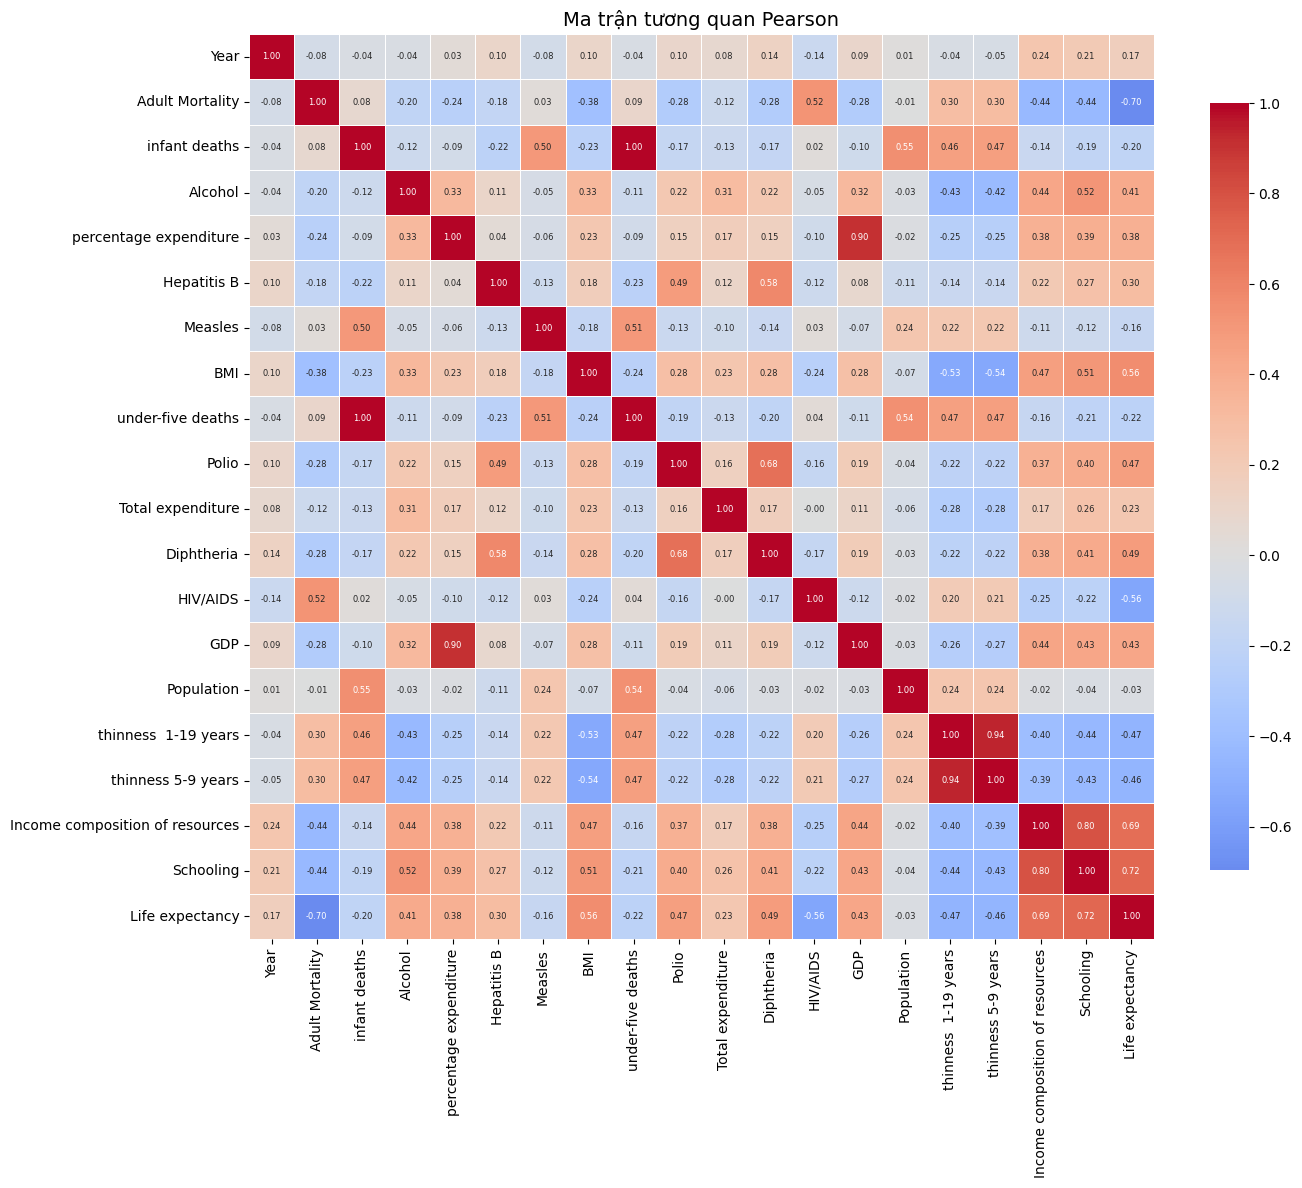

In [15]:
order = [c for c in num_cols if c != 'Life expectancy'] + ['Life expectancy']
plt.figure(figsize=(14, 12))
sns.heatmap(df_imp[order].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.4, cbar_kws={'shrink': .8}, annot_kws={'size': 6})
plt.title('Ma trận tương quan Pearson', fontsize=14); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Đa cộng tuyến rõ: `infant deaths`↔`under-five deaths` (≈1,0 — gần trùng), `GDP`↔`percentage expenditure`,
> `thinness 1-19 years`↔`thinness 5-9 years` (≈0,9), `Schooling`↔`Income composition of resources` (~0,8) → với model tuyến tính
> nên bỏ bớt một biến trong mỗi cặp.

## 9. Xếp hạng tương quan với `Life expectancy`

**Lý do:** Xếp hạng |r| để biết yếu tố nào ảnh hưởng mạnh nhất tới tuổi thọ.

/tmp/ipykernel_26521/3226746694.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_t.values, y=corr_t.index, palette=colors)


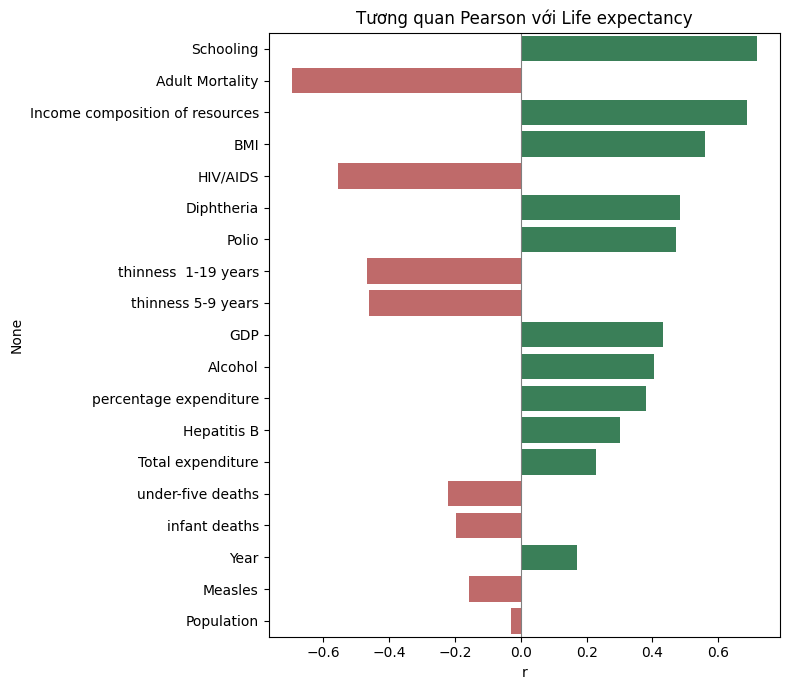

,corr_with_target
Schooling,0.717
Adult Mortality,-0.696
Income composition of resources,0.689
BMI,0.559
HIV/AIDS,-0.557
Diphtheria,0.485
Polio,0.472
thinness 1-19 years,-0.468
thinness 5-9 years,-0.463
GDP,0.432


In [16]:
corr_t = df_imp[num_cols].corr()['Life expectancy'].drop('Life expectancy').sort_values(key=np.abs, ascending=False)
plt.figure(figsize=(8, 7))
colors = ['seagreen' if v > 0 else 'indianred' for v in corr_t.values]
sns.barplot(x=corr_t.values, y=corr_t.index, palette=colors)
plt.axvline(0, color='gray', lw=.8); plt.title('Tương quan Pearson với Life expectancy'); plt.xlabel('r')
plt.tight_layout(); plt.show()
corr_t.round(3).to_frame('corr_with_target')

> 📊 **Phân tích:** Dẫn dắt tuổi thọ: **`Schooling` (0,75)** và **`Income composition of resources` (0,73)** — giáo dục & phát triển con người;
> **`Adult Mortality` (−0,70)** và **`HIV/AIDS` (−0,56)** kéo giảm mạnh; `BMI` (0,57), tỉ lệ tiêm chủng `Diphtheria`/`Polio` (~0,47) cũng tích cực.
> Gần như không liên hệ tuyến tính: **`Population` (−0,02)**, `Measles` (−0,16), `infant deaths` (−0,20). → nhóm **giáo dục - kinh tế - y tế dự phòng**
> quan trọng nhất với tuổi thọ.

## 10. Lưu dữ liệu đã xử lý ra CSV

**Lý do:** Xuất bộ sạch: tên cột đã strip, **bỏ 10 dòng thiếu target**, **điền hết feature** (trung vị theo quốc gia).
Giữ `Country`/`Status` dạng gốc (encode để dành Pipeline) và **target nguyên gốc**. Lưu `life_expectancy_processed.csv`.

In [17]:
df_imp.to_csv('life_expectancy_processed.csv', index=False)
print('Đã lưu life_expectancy_processed.csv |', df_imp.shape,
      '| missing:', int(df_imp.isna().sum().sum()))
df_imp.head()

Đã lưu life_expectancy_processed.csv | (2928, 22) | missing: 0


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


> 💾 **Kết quả:** `life_expectancy_processed.csv` — **2.928 dòng × 22 cột**, **0 missing**, target `Life expectancy` **nguyên gốc**.
>
> **Gợi ý cho bước model (tùy chọn, chưa làm sẵn để bạn chủ động):**
> - **`Status`** → nhị phân 0/1; **`Country`** (193 mức) → target/frequency encoding, **không one-hot** (quá nhiều cột). Cân nhắc bỏ `Country`
>   và để `Status` + các chỉ số đại diện cho khác biệt quốc gia.
> - **Đa cộng tuyến:** bỏ bớt một trong `infant deaths`/`under-five deaths`, `thinness 1-19`/`thinness 5-9`, `GDP`/`percentage expenditure`.
> - **Log** các biến lệch cực mạnh (`Population`, `GDP`, `Measles`, `infant deaths`...) nếu dùng model tuyến tính.
> - **Scale** (Standard/Robust) cho model nhạy khoảng cách; RF/GBM thì không cần.
> - Nếu muốn chống leakage chặt: đưa bước điền thiếu + encode vào `Pipeline` fit-trên-train.